# Collider Ring Studies (twiss_ir1ccma_hybrid_v06).

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from mint import lattice_tools as lt
from mint import beam_optics as bopt
from mint import const, xsecs
from mint.MuC import MuDecaySimulator
from mint import plot_tools as pt

import vector

## Create main collider-ring lattice

In [2]:
twiss_file = "beam-optics/twiss_ir1ccma_hybrid_v06.outx"

ring_df = lt.get_lattice_dataframe_from_tfs(twiss_file)
ring_dict = bopt.create_smoothed_lattice(
    ring_df,
    emittance_RMS=25e-6/(5e3/0.105), # meters.rad
    n_elements=120000,
    rotated=True,
    if_sublattice=False,
    midpoint=True
)
ring_lattice = lt.Lattice(**ring_dict)
ring_lattice.name = "twiss_ir1ccma_hybrid_v06"
ring_lattice.short_name = "ir1ccma_v06"

# Operation assumptions
ring_lattice.Nmu_per_bunch = 2e12
ring_lattice.finj = 5.0
ring_lattice.bunch_multiplicity = 1.0
ring_lattice.duty_factor = 1 / np.pi # 1e7 seconds per year

print(f"Lattice: {ring_lattice.name}")
print(f"Ring circumference: {ring_lattice.s(1)/1e3:.2f} km")

Setting additional dispersion_Dx to <scipy.interpolate._interpolate.interp1d object at 0x135a45ef0>
Setting additional dispersion_Dpx to <scipy.interpolate._interpolate.interp1d object at 0x135a45f40>
Setting additional betx to <scipy.interpolate._interpolate.interp1d object at 0x135a45fe0>
Setting additional bety to <scipy.interpolate._interpolate.interp1d object at 0x135a46030>
Setting additional gamx to <scipy.interpolate._interpolate.interp1d object at 0x135a46080>
Setting additional gamy to <scipy.interpolate._interpolate.interp1d object at 0x135a460d0>
Setting additional alfx to <scipy.interpolate._interpolate.interp1d object at 0x135a46120>
Setting additional alfy to <scipy.interpolate._interpolate.interp1d object at 0x135a46170>
Setting additional cov_x_xp to <scipy.interpolate._interpolate.interp1d object at 0x135a461c0>
Setting additional cov_y_yp to <scipy.interpolate._interpolate.interp1d object at 0x135a46210>
Setting additional sigma_xp to <scipy.interpolate._interpolate.

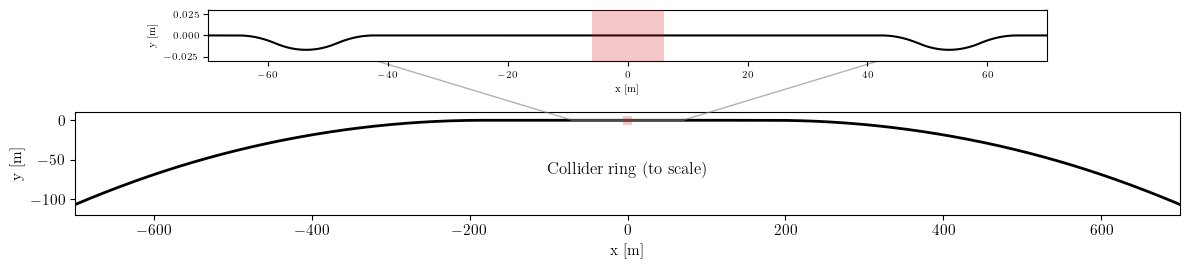

In [3]:
# Quick geometry and reference momentum profile
u = np.linspace(0, 1, 4000)

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(ring_lattice.x(u)/100, ring_lattice.y(u)/100, lw=2.0, color='black')
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.text(0.5, 0.4, "Collider ring (to scale)", transform=ax.transAxes, ha="center", fontsize=12)
ax.set_xlim(-700, 700)
ax.set_ylim(-120, 10)
ax.set_aspect("equal", adjustable="box")

# Detector box: ±6 m around IP (0, 0)
det_half = 6  # meters
det_box = plt.Rectangle((-det_half, -det_half), 2*det_half, 2*det_half,
                         linewidth=1.5, edgecolor='None', facecolor='tab:red', alpha=0.25, zorder=5)
ax.add_patch(det_box)

# Inset: chicane detail at ~x=50m, y~20cm
xl = 0.12
axins = ax.inset_axes([xl, 1.5, (1 - 2*xl), 0.5])
axins.plot(ring_lattice.x(u)/100, ring_lattice.y(u)/100, lw=1.5, color='black')
axins.set_xlim(-70, 70)
axins.set_ylim(-0.03, 0.03)
axins.tick_params(labelsize=7)
axins.set_xlabel("x [m]", fontsize=7)
axins.set_ylabel("y [m]", fontsize=7)
ax.indicate_inset_zoom(axins, edgecolor="gray", alpha=0.6)

# Detector box in inset
det_box_ins = plt.Rectangle((-det_half, -det_half), 2*det_half, 2*det_half,
                              linewidth=1.5, edgecolor='None', facecolor='tab:red', alpha=0.25, zorder=5)
axins.add_patch(det_box_ins)
# axins.set_aspect("equal", adjustable="box")

fig.tight_layout()
fig.savefig("plots/collider_ring_geometry.pdf", dpi=400)


In [91]:
ring_sims["numubar_nobd"].pos[i_weird]

VectorObject3D(x=-11380.239399723752, y=0.0, z=-71630.96005882177)

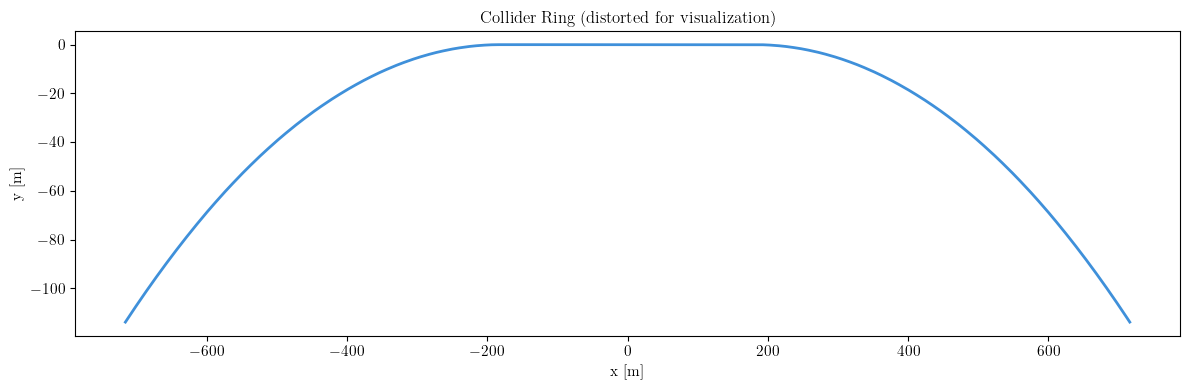

In [93]:
# Quick geometry and reference momentum profile
u = np.linspace(0, 1, 4000)

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(ring_lattice.x(u)/100, ring_lattice.y(u)/100, lw=2)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Collider Ring (distorted for visualization)")
# ax.set_ylim(-0.1,0.01)
# ax.set_xlim(-200,200)
fig.tight_layout()

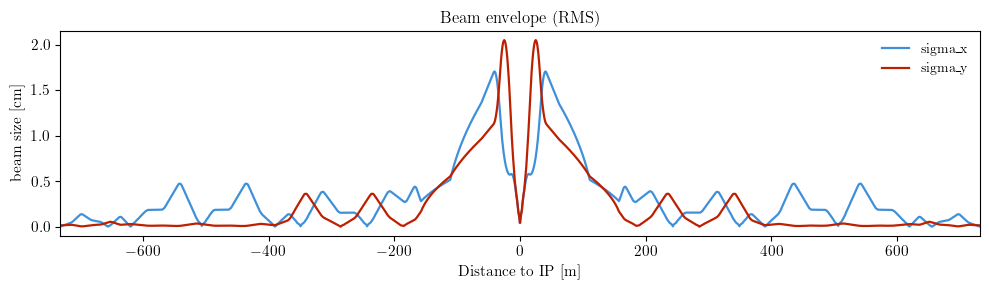

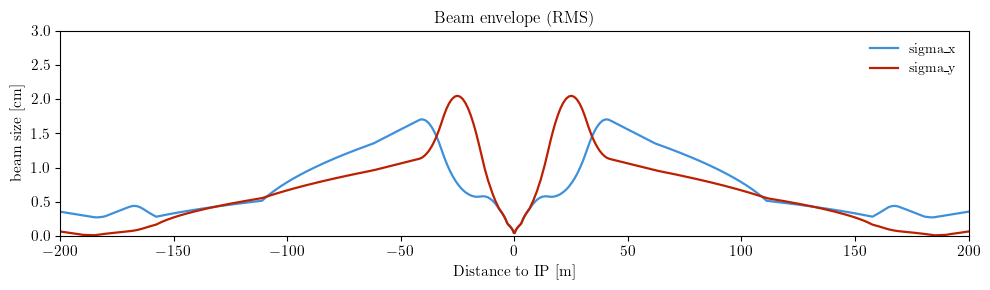

In [5]:
# Plot beam envelope (RMS) vs longitudinal position s [m]
delta_s_m = (ring_lattice.s(u) - ring_lattice.s(u).mean())*1e-2
sigma_x = ring_dict["beamsize_x"](u)
sigma_y = ring_dict["beamsize_y"](u)

fig_env, ax_env = plt.subplots(figsize=(10, 3))
ax_env.plot(delta_s_m, sigma_x, label="sigma_x", lw=1.6)
ax_env.plot(delta_s_m, sigma_y, label="sigma_y", lw=1.6)
ax_env.set_xlabel("Distance to IP [m]")
ax_env.set_ylabel("beam size [cm]")
ax_env.set_title("Beam envelope (RMS)")
ax_env.legend(frameon=False)
ax_env.set_xlim(delta_s_m.min(), delta_s_m.max())
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beam_envelope.pdf", dpi=300, bbox_inches="tight")



fig_env, ax_env = plt.subplots(figsize=(10, 3))
ax_env.plot(delta_s_m, sigma_x, label="sigma_x", lw=1.6)
ax_env.plot(delta_s_m, sigma_y, label="sigma_y", lw=1.6)
ax_env.set_xlabel("Distance to IP [m]")
ax_env.set_ylabel("beam size [cm]")
ax_env.set_ylim(1e-3*0, 3)
# ax_env.set_yscale('log')
ax_env.set_title("Beam envelope (RMS)")
ax_env.legend(frameon=False)
ax_env.set_xlim(delta_s_m.mean() - 200, delta_s_m.mean() + 200)
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beam_envelope_zoomed.pdf", dpi=300, bbox_inches="tight")


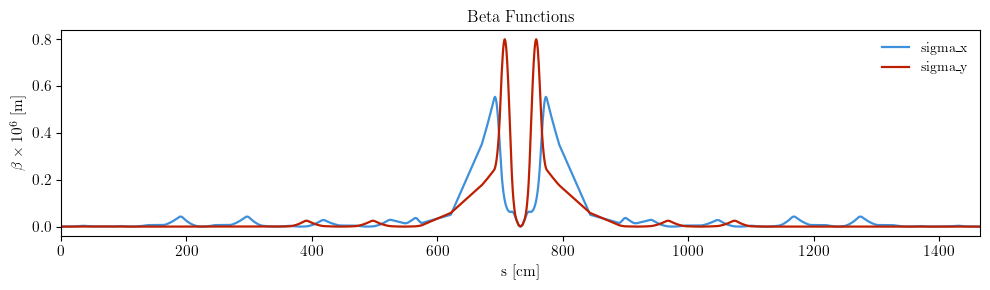

In [6]:
# Plot beam envelope (RMS) vs longitudinal position s [m]
s_m = ring_lattice.s(u) * 1e-2
sigma_x = ring_dict["betx"](u) * 1e-6
sigma_y = ring_dict["bety"](u) * 1e-6

fig_env, ax_env = plt.subplots(figsize=(10, 3))
ax_env.plot(s_m, sigma_x, label="sigma_x", lw=1.6)
ax_env.plot(s_m, sigma_y, label="sigma_y", lw=1.6)
ax_env.set_xlabel(r"s [cm]")
ax_env.set_ylabel(r"$\beta \times 10^{6}$ [m]")
ax_env.set_title("Beta Functions")
ax_env.legend(frameon=False)
ax_env.set_xlim(s_m.min(), s_m.max())
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beta_functions.pdf", dpi=300, bbox_inches="tight")


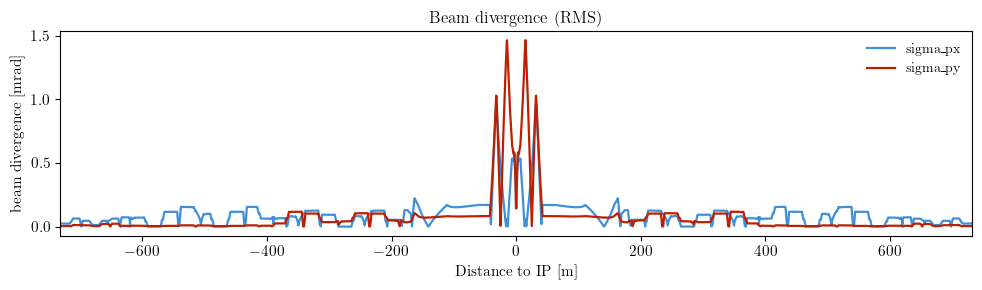

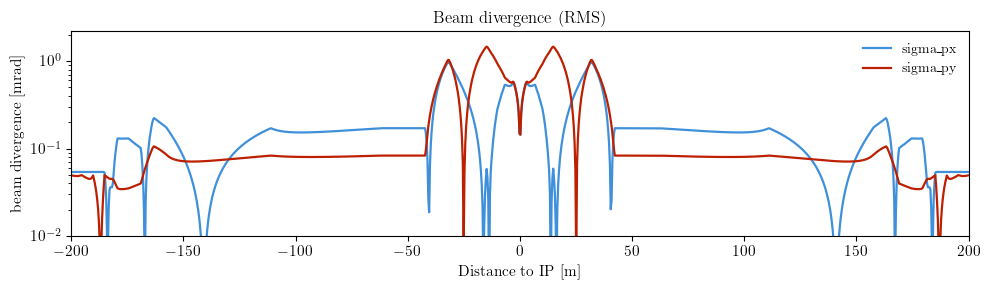

In [7]:
# Plot beam envelope (RMS) vs longitudinal position s [m]
delta_s_m = (ring_lattice.s(u) - ring_lattice.s(u).mean())*1e-2
sigma_x_mrad = ring_dict["beamdiv_x"](u)*1e3
sigma_y_mrad = ring_dict["beamdiv_y"](u)*1e3

fig_env, ax_env = plt.subplots(figsize=(10, 3))
ax_env.plot(delta_s_m, sigma_x_mrad, label=r"sigma_{px}", lw=1.6)
ax_env.plot(delta_s_m, sigma_y_mrad, label=r"sigma_{py}", lw=1.6)
ax_env.set_xlabel("Distance to IP [m]")
ax_env.set_ylabel("beam divergence [mrad]")
ax_env.set_title("Beam divergence (RMS)")
ax_env.legend(frameon=False)
ax_env.set_xlim(delta_s_m.min(), delta_s_m.max())
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beam_divergence.pdf", dpi=300, bbox_inches="tight")

# ZOOMED IN
# Plot beam envelope (RMS) vs longitudinal position s [m]
delta_s_m = (ring_lattice.s(u) - ring_lattice.s(u).mean())*1e-2
sigma_x_mrad = ring_dict["beamdiv_x"](u)*1e3
sigma_y_mrad = ring_dict["beamdiv_y"](u)*1e3

fig_env, ax_env = plt.subplots(figsize=(10, 3))
ax_env.plot(delta_s_m, sigma_x_mrad, label=r"sigma_{px}", lw=1.6)
ax_env.plot(delta_s_m, sigma_y_mrad, label=r"sigma_{py}", lw=1.6)
ax_env.set_xlabel("Distance to IP [m]")
ax_env.set_ylabel("beam divergence [mrad]")
ax_env.set_title("Beam divergence (RMS)")
ax_env.legend(frameon=False)
ax_env.set_yscale('log')
ax_env.set_ylim(0.01, None)
ax_env.set_xlim(delta_s_m.mean() - 200, delta_s_m.mean() + 200)
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beam_divergence_zoomed.pdf", dpi=300, bbox_inches="tight")

## Simulate forward neutrino flux

In [3]:
n_evals = 1e6

ring_sims = {
    "numubar": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="numubar", direction="right", n_evals=n_evals, beam_dynamics=True),
    "nue": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="nue", direction="right", n_evals=n_evals, beam_dynamics=True),
    "numubar_nobd": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="numubar", direction="right", n_evals=n_evals, beam_dynamics=False),
    "nue_nobd": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="nue", direction="right", n_evals=n_evals, beam_dynamics=False),
    "numu": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="numu", direction="left", n_evals=n_evals, beam_dynamics=True),
    "numu_nobd": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="numu", direction="left", n_evals=n_evals, beam_dynamics=False),
}

for flavor, sim in ring_sims.items():
    sim.decay_muons()

    if ring_sims[flavor]=="numu" or ring_sims[flavor]=="numu_nobd":
        sim.place_muons_on_lattice(lattice=ring_lattice, direction="counter-clockwise")
    else:
        sim.place_muons_on_lattice(lattice=ring_lattice, direction="clockwise")

In [89]:
i_weird = ring_sims["numubar_nobd"].pmu.costheta.argmin()
ring_sims["numubar_nobd"].pos[i_weird]

VectorObject3D(x=-11380.239399723752, y=0.0, z=-71630.96005882177)

In [103]:
i_weird = ring_sims_no_chicane["numubar_nobd"].pmu.costheta.argmin()
ring_sims_no_chicane["numubar_nobd"].pos.z.min()

np.float64(-17945.34021849624)

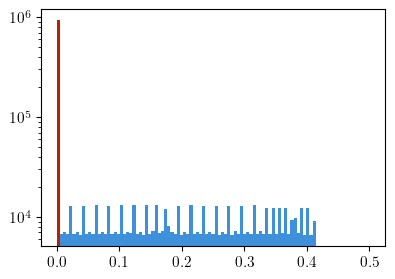

In [95]:
_ = plt.hist(np.arccos(ring_sims["numubar_nobd"].pmu.costheta), bins=np.linspace(0, 0.5, 100))
# plt.hist(np.arccos(ring_sims_straight["numubar_nobd"].pmu.costheta), bins=np.linspace(0, 0.5, 100))
_ = plt.hist(np.arccos(ring_sims_no_chicane["numubar_nobd"].pmu.costheta), bins=np.linspace(0, 0.5, 100))
plt.yscale('log')


In [4]:
# Detector and running assumptions for event-rate estimate
det_radius = 2e2  # cm (2 m radius)
detector_length_cm = 10e2  # 10 m target depth
rho_g_cm3 = 1.00
nucleon_column_density = rho_g_cm3 * detector_length_cm / const.m_proton_in_g
detector_area_cm2 = np.pi * det_radius**2

det_location = np.array([0, 0.0, 1e5])  # 1 km downstream
det_location2 = np.array([0, 0.0, -1e5])  # 1 km upstream for mu- decay

bunches_per_year = (
    ring_lattice.finj
    * ring_lattice.bunch_multiplicity
    * ring_lattice.duty_factor
    * const.s_in_year
)


/var/folders/84/k7jzjrjn68595pl9grlw_7cm0000gq/T/ipykernel_62256/273792356.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


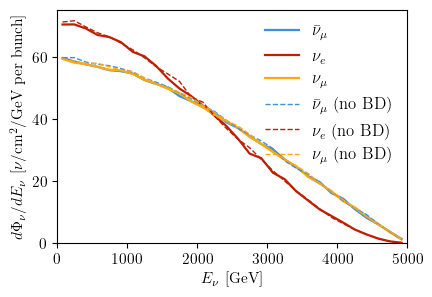

In [5]:
# Forward detector setup (on-axis, downstream)
energy_edges = np.linspace(0, 5e3, 31)
energy_centers = 0.5 * (energy_edges[1:] + energy_edges[:-1])

flux_results = {}
for flavor, sim in ring_sims.items():
    if ring_sims[flavor] == "numu" or ring_sims[flavor] == "numu_nobd":
        loc = det_location2
    else:
        loc = det_location
    e_edges, flux = sim.get_flux_at_generic_location(
        det_location=loc,
        det_radius=det_radius,
        ebins=energy_edges,
        per_cm2=True,
        normalization=1,
    )

    if np.isscalar(e_edges):
        flux = np.zeros_like(energy_centers)
    flux_results[flavor] = flux

fig, ax = pt.std_fig()
label = {"numubar": r"$\bar\nu_\mu$", "nue": r"$\nu_e$", "numu": r"$\nu_\mu$"}
for i, flavor in enumerate(["numubar", "nue", "numu"]):
    ax.plot(energy_centers, flux_results[flavor], lw=1.6, label=label[flavor])
    # ax[i].set_yscale("log")
    ax.set_xlabel(r"$E_\nu$ [GeV]")

plt.gca().set_prop_cycle(None)
for i, flavor in enumerate(["numubar", "nue", "numu"]):
    ax.plot(energy_centers, flux_results[flavor+'_nobd'], lw=1, ls='--', label=label[flavor]+r' (no BD)')
    # ax[i].set_yscale("log")
    ax.set_xlabel(r"$E_\nu$ [GeV]")

ax.set_xlim(0, 5e3)
ax.set_ylim(0, None)
ax.legend(frameon=False, fontsize=12)
ax.set_ylabel(r"$d\Phi_\nu/dE_\nu$ [$\nu$/cm$^{2}$/GeV per bunch]")
fig.tight_layout()
fig.savefig("plots/hybrid_v06_flux_spectrum.pdf", dpi=300, bbox_inches="tight")

In [11]:
sim.weights, sim.pnu

(array([[ 8265.463804  ],
        [ 3442.50093859],
        [ 2524.76937306],
        ...,
        [49980.48445408],
        [48271.35303415],
        [48182.92000597]], shape=(937643, 1)),
 MomentumNumpy4D([(-1.06500921e-04, -2.00924876e-01, 5.26385338e-01, 5.63429092e-01),
                  (-1.78572461e-05,  3.84438026e-02, 2.16637669e-01, 2.20022285e-01),
                  (-3.56845196e-05, -1.33925133e-04, 2.06710920e-01, 2.06710966e-01),
                  ...,
                  (-3.03389486e-04,  1.99387775e+03, 4.56949429e+03, 4.98556181e+03),
                  (-4.29883075e-04, -1.49244215e+03, 4.76017637e+03, 4.98865339e+03),
                  ( 1.01259235e-03, -1.75791638e+03, 4.66409599e+03, 4.98438175e+03)],
                 shape=(937643,), dtype=[('x', '<f8'), ('y', '<f8'), ('z', '<f8'), ('t', '<f8')]))

In [6]:
def get_event_rate_at_annuli_event_based(sim, flavor, det_loc=det_location, r_edges=np.linspace(0.0, det_radius, 51), energy_centers=None, nucleon_column_density=None, xsecs=None, bunches_per_year=None):
    """
    Event-based binning: for each event, compute its radial distance to the detector axis, bin its weight into the appropriate annulus, and apply the probability of interaction at the detector.
    Returns: event rate per annulus (events per year per m)
    """
    import numpy as np
    # Get event positions and directions
    det_vector = vector.array({"x": det_loc[0], "y": det_loc[1], "z": det_loc[2]})
    distances = det_vector - sim.pos
    neutrino_direction = sim.pnu.to_3D().unit()
    sintheta = np.sqrt(1 - distances.unit().dot(neutrino_direction) ** 2)
    radial_distance = sintheta * distances.mag

    # Only consider events that are forward-going and within energy range
    dotprod = distances.dot(neutrino_direction)
    in_acceptance = (dotprod > 0) & (sim.pnu["E"] > 0)

    # Bin by radial distance
    r_edges = np.asarray(r_edges)
    weights = sim.weights.flatten()
    # Only use accepted events
    r_accepted = radial_distance[in_acceptance]
    w_accepted = weights[in_acceptance]
    E_accepted = sim.pnu["E"][in_acceptance]

    # Calculate interaction probability for each event
    # xsecs should be a function or array: xsecs[flavor](energy_centers)
    # For each event, interpolate the cross section at its energy
    if xsecs is not None and energy_centers is not None and nucleon_column_density is not None and bunches_per_year is not None:
        sigma = xsecs[flavor](E_accepted)  # shape: (n_events,)
        p_int = sigma * nucleon_column_density  # probability of interaction per event
        event_weights = w_accepted * p_int * bunches_per_year
    else:
        event_weights = w_accepted  # fallback: just flux, not event rate

    # Bin the event rates by annulus
    annulus_counts, _ = np.histogram(r_accepted, bins=r_edges, weights=event_weights)
    dr = np.diff(r_edges)  # cm
    # Convert to per meter (multiply by 100)
    dN_dr_per_year_per_cm = annulus_counts / dr
    dN_dr_per_year_per_m = dN_dr_per_year_per_cm * 100.0
    return dN_dr_per_year_per_m

In [7]:
r_edges = np.linspace(0.0, 10e2, 200)  # cm
dN_dr_per_year_per_m_numubar = get_event_rate_at_annuli_event_based(ring_sims["numubar"], "numubar", r_edges=r_edges)
dN_dr_per_year_per_m_nue = get_event_rate_at_annuli_event_based(ring_sims["nue"], "nue", r_edges=r_edges)
dN_dr_per_year_per_m_numubar_noBD = get_event_rate_at_annuli_event_based(ring_sims["numubar_nobd"], "numubar", r_edges=r_edges)
dN_dr_per_year_per_m_nue_noBD = get_event_rate_at_annuli_event_based(ring_sims["nue_nobd"], "nue", r_edges=r_edges)
dN_dr_per_year_per_m_numu = get_event_rate_at_annuli_event_based(ring_sims["numu"], "numu",det_loc=det_location2, r_edges=r_edges)
dN_dr_per_year_per_m_numu_noBD = get_event_rate_at_annuli_event_based(ring_sims["numu_nobd"], "numu",det_loc=det_location2, r_edges=r_edges)


In [8]:
# Create a new lattice by removing curves and chicanes (all ANGLE=0)
import copy
import pandas as pd

def make_straight_lattice_from_midpoint(df):
    n = len(df)
    mid = n // 2
    # Helper to traverse in one direction
    def traverse(start, stop, step):
        out = []
        nonzero_count = 0
        for i in range(start, stop, step):
            row = df.iloc[i].copy()
            if row["ANGLE"] != 0:
                if nonzero_count < 3:
                    row["ANGLE"] = 0
                    nonzero_count += 1
                else:
                    break
            out.append(row)
        return out
    # Go left from midpoint (including midpoint)
    left = traverse(mid, -1, -1)
    # Go right from midpoint+1
    right = traverse(mid+1, n, 1)
    # Combine, reverse left to original order
    new_rows = list(reversed(left)) + right
    new_df = pd.DataFrame(new_rows).reset_index(drop=True)
    # Set all ANGLE to 0 for safety
    new_df["ANGLE"] = 0

    new_df["px"] = np.sqrt(new_df["px"]**2 + new_df["py"]**2)
    new_df["py"] = 0.0

    new_df.attrs = df.attrs.copy()
    return new_df

# Apply to ring_df
straight_df = make_straight_lattice_from_midpoint(ring_df)

# You can now use straight_df to create a new lattice or for further analysis
display(straight_df)

,NAME,KEYWORD,S,L,ANGLE,BETX,ALFX,MUX,BETY,ALFY,...,DPX,DY,DPY,bending_magnet,GAMMAX,GAMMAY,x,y,px,py
0,START_SD_CHRCOR,MARKER,553.000000,0.0,0,16610.16686,-733.693709,3.243793,222.950485,-22.807899,...,-3.832597e-07,0,0,False,32.408311,2.33774,537.729916,-110.590293,5000.0,0.0
1,END_CHRCOR,MARKER,553.000000,0.0,0,16610.16686,-733.693709,3.243793,222.950485,-22.807899,...,-3.832597e-07,0,0,False,32.408311,2.33774,537.729916,-110.590293,5000.0,0.0
2,START_IR1,MARKER,553.000000,0.0,0,16610.16686,-733.693709,3.243793,222.950485,-22.807899,...,-3.832597e-07,0,0,False,32.408311,2.33774,537.729916,-110.590293,5000.0,0.0
3,START_IR1L,MARKER,553.000000,0.0,0,16610.16686,-733.693709,3.243793,222.950485,-22.807899,...,-3.832597e-07,0,0,False,32.408311,2.33774,537.729916,-110.590293,5000.0,0.0
4,IDR3,DRIFT,558.000000,10.0,0,24757.31174,-895.735266,3.243833,509.472971,-34.496598,...,-3.832597e-07,0,0,False,32.408311,2.33774,537.729916,-110.590293,5000.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,IDR3,DRIFT,906.907102,10.0,0,24757.31174,895.735266,4.743667,509.472971,34.496598,...,3.832597e-07,0,0,False,32.408311,2.33774,857.469675,-250.242024,5000.0,0.0
119,END_IR1R,MARKER,911.907102,0.0,0,16610.16686,733.693709,4.743707,222.950485,22.807899,...,3.832597e-07,0,0,False,32.408311,2.33774,866.633714,-254.244572,5000.0,0.0
120,END_IR1,MARKER,911.907102,0.0,0,16610.16686,733.693709,4.743707,222.950485,22.807899,...,3.832597e-07,0,0,False,32.408311,2.33774,866.633714,-254.244572,5000.0,0.0
121,START_CHRCOR,MARKER,911.907102,0.0,0,16610.16686,733.693709,4.743707,222.950485,22.807899,...,3.832597e-07,0,0,False,32.408311,2.33774,866.633714,-254.244572,5000.0,0.0


In [9]:
# Create a new lattice by keeping the end curves but maintaining chicanes at zero angle
import copy
import pandas as pd

def make_curved_lattice_with_zero_chicanes(df):
    n = len(df)
    mid = n // 2
    # Helper to traverse in one direction
    def traverse(start, stop, step):
        out = []
        nonzero_count = 0
        for i in range(start, stop, step):
            row = df.iloc[i].copy()
            if row["ANGLE"] != 0:
                # Only set the first 3 nonzero ANGLEs to zero (chicanes), keep the rest as curves
                if nonzero_count < 3:
                    row["ANGLE"] = 0
                    nonzero_count += 1
                # After 3 chicanes, keep the rest of the curves as is
            out.append(row)
        return out
    # Go left from midpoint (including midpoint)
    left = traverse(mid, -1, -1)
    # Go right from midpoint+1
    right = traverse(mid+1, n, 1)
    # Combine, reverse left to original order
    new_rows = list(reversed(left)) + right
    new_df = pd.DataFrame(new_rows).reset_index(drop=True)
    new_df.attrs = df.attrs.copy()
    return new_df

# Apply to ring_df
curved_df = make_curved_lattice_with_zero_chicanes(ring_df)

# You can now use curved_df to create a new lattice or for further analysis
display(curved_df[380:400])

,NAME,KEYWORD,S,L,ANGLE,BETX,ALFX,MUX,BETY,ALFY,...,DPX,DY,DPY,bending_magnet,GAMMAX,GAMMAY,x,y,px,py
380,IDR2,DRIFT,621.426775,92.253551,0.0,50556.25559,-1675.658076,3.743662,58309.41591,-875.127547,...,5.658303e-08,0,0,False,55.538745,13.134229,558.165722,-119.515976,4582.019369,-2001.274219
381,IB2,SBEND,670.553551,6.000000,0.0,349234.32890,-4403.852889,3.743721,175992.47980,-1520.369870,...,1.450074e-03,0,0,True,55.532689,13.134229,642.707234,-156.440906,4582.019369,-2001.274219
382,DR,DRIFT,673.703551,0.300000,0.0,377528.77430,-4578.516402,3.743722,185701.13440,-1561.742691,...,2.900088e-03,0,0,False,55.526399,13.134229,648.202167,-158.850405,4576.196342,-2014.553805
383,IB1,SBEND,678.853551,10.000000,0.0,426156.74450,-4863.761323,3.743724,202135.43670,-1629.383971,...,3.323089e-08,0,0,True,55.510503,13.134229,648.476739,-158.971278,4576.196342,-2014.553805
384,DR,DRIFT,684.003551,0.300000,0.0,477721.66230,-5148.837716,3.743726,219266.44420,-1697.025250,...,-2.900022e-03,0,0,False,55.493675,13.134229,657.640765,-162.973821,4587.803841,-1987.977847
385,IB3,SBEND,687.153551,6.000000,0.0,510708.92450,-5323.284981,3.743727,230088.02760,-1738.398072,...,-1.450013e-03,0,0,True,55.486330,13.134229,657.916033,-163.093100,4587.803841,-1987.977847
386,DR,DRIFT,690.303551,0.300000,0.0,544794.94980,-5497.685239,3.743728,241170.25990,-1779.770893,...,-6.266689e-16,0,0,False,55.478752,13.134229,663.417931,-165.486653,4582.019369,-2001.274219
387,IQF2,QUADRUPOLE,690.953551,1.000000,0.0,550956.68140,-3510.829886,3.743728,243935.42330,-2682.860727,...,-3.986030e-16,0,0,False,22.371863,29.506755,663.692852,-165.606729,4582.019369,-2001.274219
388,IQF2,QUADRUPOLE,691.953551,1.000000,0.0,553932.84400,541.951396,3.743729,251151.60540,-4550.965561,...,5.930263e-17,0,0,False,0.530231,82.465284,664.609256,-166.006984,4582.019369,-2001.274219
389,IQF2,QUADRUPOLE,692.953551,1.000000,0.0,548799.46640,4578.862342,3.743729,262228.48010,-6552.993073,...,5.167733e-16,0,0,False,38.203356,163.756886,665.525660,-166.407239,4582.019369,-2001.274219


In [10]:
# Build a new Lattice object from the straight_df
from mint import lattice_tools as lt

straight_dict = bopt.create_smoothed_lattice(
    straight_df,
    emittance_RMS=25e-6/(5e3/0.105), # meters.rad
    n_elements=120000,
    rotated=True,
    if_sublattice=False,
    midpoint=True
)

# Build the new Lattice object
new_lattice = lt.Lattice(**straight_dict)
new_lattice.name = "straightened_lattice"
new_lattice.short_name = "straight"

# Operation assumptions
new_lattice.Nmu_per_bunch = 2e12
new_lattice.finj = 5.0
new_lattice.bunch_multiplicity = 1.0
new_lattice.duty_factor = 1 / np.pi # 1e7 seconds per year


Setting additional dispersion_Dx to <scipy.interpolate._interpolate.interp1d object at 0x137f4a4e0>
Setting additional dispersion_Dpx to <scipy.interpolate._interpolate.interp1d object at 0x137f4a170>
Setting additional betx to <scipy.interpolate._interpolate.interp1d object at 0x137f49f40>
Setting additional bety to <scipy.interpolate._interpolate.interp1d object at 0x137f49fe0>
Setting additional gamx to <scipy.interpolate._interpolate.interp1d object at 0x137f4a120>
Setting additional gamy to <scipy.interpolate._interpolate.interp1d object at 0x137f49f90>
Setting additional alfx to <scipy.interpolate._interpolate.interp1d object at 0x137f48190>
Setting additional alfy to <scipy.interpolate._interpolate.interp1d object at 0x137f49e50>
Setting additional cov_x_xp to <scipy.interpolate._interpolate.interp1d object at 0x137f49ea0>
Setting additional cov_y_yp to <scipy.interpolate._interpolate.interp1d object at 0x137f49e00>
Setting additional sigma_xp to <scipy.interpolate._interpolate.

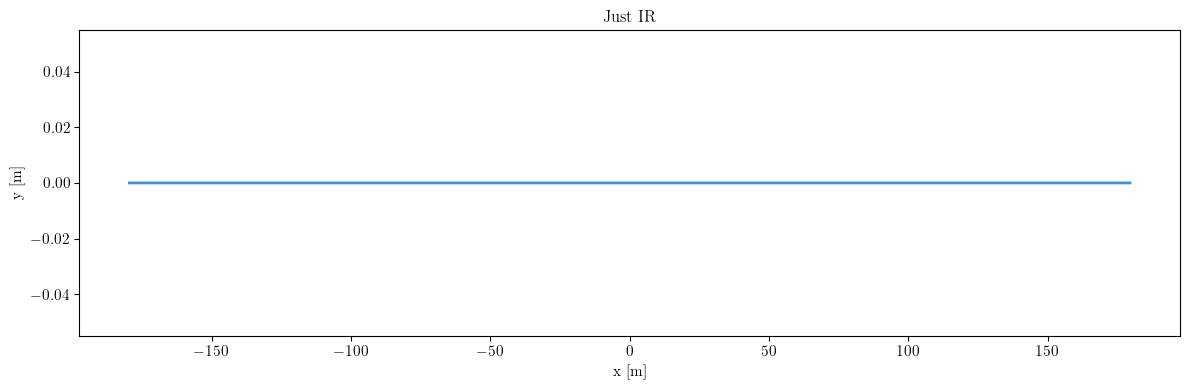

In [17]:
# Quick geometry and reference momentum profile
u = np.linspace(0, 1, 4000)

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(new_lattice.x(u)/100, new_lattice.y(u)/100, lw=2)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Just IR")
#ax.set_ylim(-0.1,0.01)
#ax.set_xlim(-200,200)
fig.tight_layout()

In [11]:
# Build a new Lattice object from the straight_df
from mint import lattice_tools as lt

no_chicane = bopt.create_smoothed_lattice(
    curved_df,
    emittance_RMS=25e-6/(5e3/0.105), # meters.rad
    n_elements=120000,
    rotated=True,
    if_sublattice=False,
    midpoint=True
)

# Build the new Lattice object
new_lattice2 = lt.Lattice(**no_chicane)
new_lattice2.name = "no_chicane_lattice"
new_lattice2.short_name = "no_chicane"

# Operation assumptions
new_lattice2.Nmu_per_bunch = 2e12
new_lattice2.finj = 5.0
new_lattice2.bunch_multiplicity = 1.0
new_lattice2.duty_factor = 1 / np.pi # 1e7 seconds per year

Setting additional dispersion_Dx to <scipy.interpolate._interpolate.interp1d object at 0x137f49130>
Setting additional dispersion_Dpx to <scipy.interpolate._interpolate.interp1d object at 0x137f491d0>
Setting additional betx to <scipy.interpolate._interpolate.interp1d object at 0x137f492c0>
Setting additional bety to <scipy.interpolate._interpolate.interp1d object at 0x137f49180>
Setting additional gamx to <scipy.interpolate._interpolate.interp1d object at 0x137f48fa0>
Setting additional gamy to <scipy.interpolate._interpolate.interp1d object at 0x137f49090>
Setting additional alfx to <scipy.interpolate._interpolate.interp1d object at 0x137f48ff0>
Setting additional alfy to <scipy.interpolate._interpolate.interp1d object at 0x137f49040>
Setting additional cov_x_xp to <scipy.interpolate._interpolate.interp1d object at 0x137f48eb0>
Setting additional cov_y_yp to <scipy.interpolate._interpolate.interp1d object at 0x137f48f00>
Setting additional sigma_xp to <scipy.interpolate._interpolate.

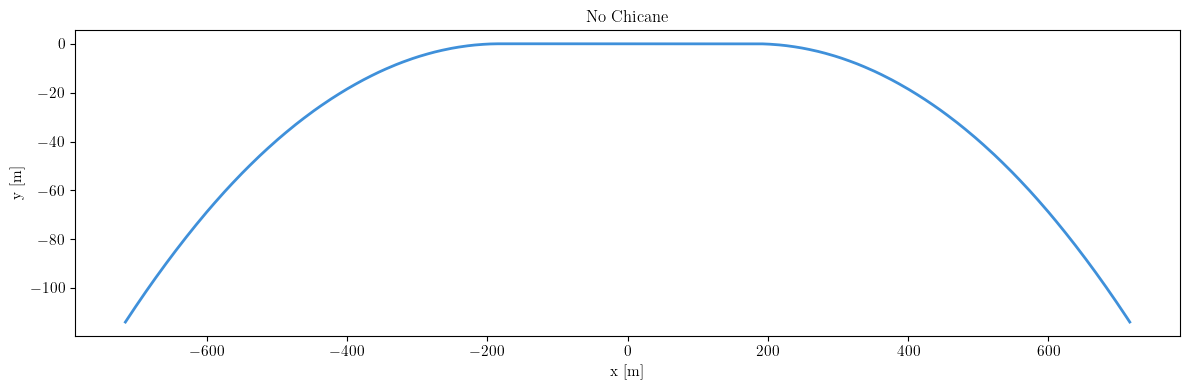

In [57]:
# Quick geometry and reference momentum profile

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(new_lattice2.x(u)/100, new_lattice2.y(u)/100, lw=2)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("No Chicane")
#ax.set_ylim(-0.1,0.01)
#ax.set_xlim(-200,200)
fig.tight_layout()

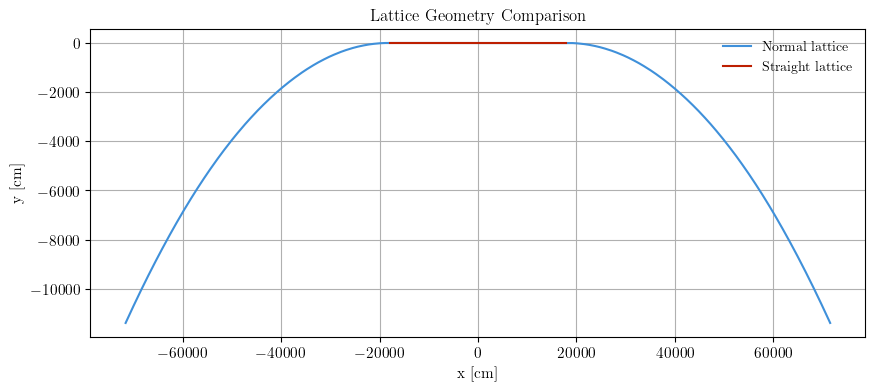

In [20]:
# Compare the geometry of the normal and straight lattices
import matplotlib.pyplot as plt
u = np.linspace(0, 1, 1000)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ring_lattice.x(u), ring_lattice.y(u), label="Normal lattice")
ax.plot(new_lattice.x(u), new_lattice.y(u), label="Straight lattice")
# Mark detector location (projected onto x-y plane)
# if 'det_location' in globals():
#     ax.plot(det_location[0], det_location[1], 'ro', markersize=10, label='Detector')
#     ax.annotate('Detector', (det_location[0], det_location[1]), textcoords="offset points", xytext=(10,10), ha='left', color='red', fontsize=12)
ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("Lattice Geometry Comparison")
ax.legend()
ax.grid(True)
plt.show()

In [12]:
ring_sims_straight = {
    "numubar": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="numubar", direction="right", n_evals=n_evals, beam_dynamics=True),
    "nue": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="nue", direction="right", n_evals=n_evals, beam_dynamics=True),
    "numubar_nobd": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="numubar", direction="right", n_evals=n_evals, beam_dynamics=False),
    "nue_nobd": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="nue", direction="right", n_evals=n_evals, beam_dynamics=False),
}

for _, IR_sim in ring_sims_straight.items():
    IR_sim.decay_muons()
    IR_sim.place_muons_on_lattice(lattice=new_lattice, direction="clockwise")

In [13]:
ring_sims_no_chicane = {
    "numubar": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="numubar", direction="right", n_evals=n_evals, beam_dynamics=True),
    "nue": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="nue", direction="right", n_evals=n_evals, beam_dynamics=True),
    "numubar_nobd": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="numubar", direction="right", n_evals=n_evals, beam_dynamics=False),
    "nue_nobd": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="nue", direction="right", n_evals=n_evals, beam_dynamics=False),
}

for _, IR_sim in ring_sims_no_chicane.items():
    IR_sim.decay_muons()
    IR_sim.place_muons_on_lattice(lattice=new_lattice2, direction="clockwise")

In [14]:
dN_dr_per_year_per_m_numubar_straight = get_event_rate_at_annuli_event_based(ring_sims_straight["numubar"], "numubar", r_edges=r_edges)
dN_dr_per_year_per_m_nue_straight = get_event_rate_at_annuli_event_based(ring_sims_straight["nue"], "nue", r_edges=r_edges)
dN_dr_per_year_per_m_numubar_noBD_straight = get_event_rate_at_annuli_event_based(ring_sims_straight["numubar_nobd"], "numubar", r_edges=r_edges)
dN_dr_per_year_per_m_nue_noBD_straight = get_event_rate_at_annuli_event_based(ring_sims_straight["nue_nobd"], "nue", r_edges=r_edges)


In [15]:
dN_dr_per_year_per_m_numubar_no_chicane = get_event_rate_at_annuli_event_based(ring_sims_no_chicane["numubar"], "numubar", r_edges=r_edges)
dN_dr_per_year_per_m_nue_no_chicane = get_event_rate_at_annuli_event_based(ring_sims_no_chicane["nue"], "nue", r_edges=r_edges)
dN_dr_per_year_per_m_numubar_noBD_no_chicane = get_event_rate_at_annuli_event_based(ring_sims_no_chicane["numubar_nobd"], "numubar", r_edges=r_edges)
dN_dr_per_year_per_m_nue_noBD_no_chicane = get_event_rate_at_annuli_event_based(ring_sims_no_chicane["nue_nobd"], "nue", r_edges=r_edges)


In [25]:
np.sum(sim.weights)

np.float64(91823708353.409)

/var/folders/84/k7jzjrjn68595pl9grlw_7cm0000gq/T/ipykernel_62256/1851321419.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


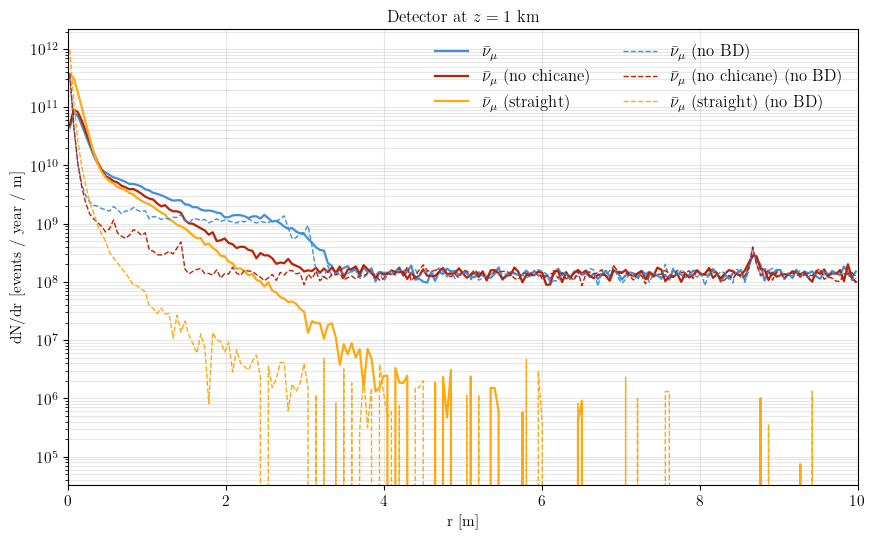

In [16]:
# plot
fig, ax = pt.std_fig(figsize=(10, 6))

r_centers = 0.5 * (r_edges[1:] + r_edges[:-1])
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numubar, lw=1.6, label=label["numubar"])
# ax.plot(r_centers/100.0, dN_dr_per_year_per_m_nue, lw=1.6, label=label["nue"])
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numubar_no_chicane, lw=1.6, label=label["numubar"]+" (no chicane)")
# ax.plot(r_centers/100.0, dN_dr_per_year_per_m_nue_no_chicane, lw=1.6, label=label["nue"]+" (no chicane)")
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numubar_straight, lw=1.6, label=label["numubar"]+" (straight)")
# ax.plot(r_centers/100.0, dN_dr_per_year_per_m_nue_straight, lw=1.6, label=label["nue"]+" (straight)")
# ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numu, lw=1.6, label=label["numu"])

plt.gca().set_prop_cycle(None)

ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numubar_noBD, lw=1., ls='--', label=label["numubar"]+r' (no BD)')
# ax.plot(r_centers/100.0, dN_dr_per_year_per_m_nue_noBD, lw=1., ls='--', label=label["nue"]+r' (no BD)')
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numubar_noBD_no_chicane, lw=1., ls='--', label=label["numubar"]+" (no chicane)"+r' (no BD)')
# ax.plot(r_centers/100.0, dN_dr_per_year_per_m_nue_noBD_no_chicane, lw=1., ls='--', label=label["nue"]+" (no chicane)"+r' (no BD)')
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numubar_noBD_straight, lw=1., ls='--', label=label["numubar"]+" (straight)"+r' (no BD)')
# ax.plot(r_centers/100.0, dN_dr_per_year_per_m_nue_noBD_straight, lw=1., ls='--', label=label["nue"]+" (straight)"+r' (no BD)')
# ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numu_noBD, lw=1., ls='--', label=label["numu"]+r' (no BD)')

ax.set_xlabel("r [m]")
ax.set_ylabel("dN/dr [events / year / m]")
ax.set_xlim(0, 10)
# ax.set_xscale
ax.grid(True, which='both', ls='-', alpha=0.3)
#ax.set_ylim(1e9, 4e11)
ax.set_yscale('log')
ax.legend(frameon=False, fontsize=12, ncol=2)
ax.set_title(r"Detector at $z = 1$ km")
fig.tight_layout()
fig.savefig("plots/hybrid_v06_event_rate_radial.pdf", dpi=300, bbox_inches="tight")

## Estimate forward event rate

Estimated total forward event rate (numubar): 9.754e+09 events/year
Estimated total forward event rate (nue):  8.514e+09 events/year
Estimated total forward event rate (numu):  9.754e+09 events/year


/var/folders/84/k7jzjrjn68595pl9grlw_7cm0000gq/T/ipykernel_5916/3253303844.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


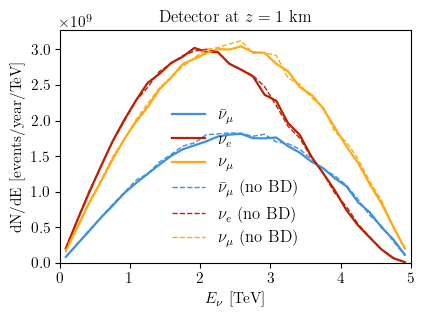

In [27]:
GeV_to_TeV = 1e-3
event_results = {}
for flavor in ["numubar", "nue", "numu"]:
    sigma_tot = xsecs.total_xsecs[flavor](energy_centers)
    p_int = sigma_tot * nucleon_column_density

    # Here we multiply back by the det area.
    dN_dE_per_decay = flux_results[flavor] * detector_area_cm2 * p_int

    # dN/dE per year
    dN_dE_per_year = dN_dE_per_decay * bunches_per_year

    event_results[flavor] = {
        "dN_dE_per_decay": dN_dE_per_decay,
        "dN_dE_per_year": dN_dE_per_year,
    }


for flavor in ["numubar", "nue", "numu"]:
    sigma_tot = xsecs.total_xsecs[flavor](energy_centers)
    p_int = sigma_tot * nucleon_column_density

    # Here we multiply back by the det area.
    dN_dE_per_decay = flux_results[flavor+'_nobd'] * detector_area_cm2 * p_int

    # dN/dE per year
    dN_dE_per_year = dN_dE_per_decay * bunches_per_year

    event_results[flavor+'_nobd'] = {
        "dN_dE_per_decay": dN_dE_per_decay,
        "dN_dE_per_year": dN_dE_per_year,
    }

fig, ax = pt.std_fig()
for flavor in ["numubar", "nue", "numu"]:
    ax.plot(energy_centers*GeV_to_TeV, event_results[flavor]["dN_dE_per_year"]/GeV_to_TeV, lw=1.6, label=label[flavor])
plt.gca().set_prop_cycle(None)
for flavor in ["numubar", "nue", "numu"]:
    ax.plot(energy_centers*GeV_to_TeV, event_results[flavor+"_nobd"]["dN_dE_per_year"]/GeV_to_TeV, lw=1., ls='--', label=label[flavor]+r' (no BD)')
    # ax.set_yscale("log")
ax.set_xlabel(r"$E_\nu$ [TeV]")
ax.set_ylabel(r"dN/dE [events/year/TeV]")
ax.set_xlim(0, 5)
ax.set_ylim(0, None)
ax.legend(frameon=False, fontsize=12)
ax.set_title(r"Detector at $z = 1$ km")
fig.tight_layout()

tot_numu = np.trapezoid(event_results["numubar"]["dN_dE_per_year"], energy_centers)
tot_nue = np.trapezoid(event_results["nue"]["dN_dE_per_year"], energy_centers)
tot_numu = np.trapezoid(event_results["numu"]["dN_dE_per_year"], energy_centers)

print(f"Estimated total forward event rate (numubar): {tot_numu:.3e} events/year")
print(f"Estimated total forward event rate (nue):  {tot_nue:.3e} events/year")
print(f"Estimated total forward event rate (numu):  {tot_numu:.3e} events/year")

fig.savefig("plots/hybrid_v06_event_rate_spectrum.pdf", dpi=300, bbox_inches="tight")

## 2D Histogram of Energy vs. Detector radius

In [126]:

def E_vs_radius_event_map(sim, flavor, det_location=det_location, ebins=energy_edges, r_edges=r_edges):
    det_vector = vector.array({"x": det_location[0], "y": det_location[1], "z": det_location[2]})
    distances = det_vector - sim.pos
    neutrino_direction = sim.pnu.to_3D().unit()
    sintheta = np.sqrt(1 - distances.unit().dot(neutrino_direction) ** 2)
    radial_distance = sintheta * distances.mag

    dotprod = distances.dot(neutrino_direction)
    in_acceptance = (dotprod > 0) & (sim.pnu["E"] > 0)

    sigma_tot = xsecs.total_xsecs[flavor](energy_centers)
    p_int = sigma_tot * nucleon_column_density

    # Here we multiply back by the det area.
    dN_dE_per_decay = flux_results[flavor] * detector_area_cm2 * p_int

    # dN/dE per year
    dN_dE_per_year = dN_dE_per_decay * bunches_per_year

    radii = radial_distance[in_acceptance] * detector_area_cm2 * p_int * bunches_per_year

    # Compute the 2D histogram
    hist, xedges, yedges = np.histogram2d(radii, dN_dE_per_year, bins=[r_edges, ebins])
    return hist, xedges, yedges

In [128]:
event_results = {}
for flavor in ["numubar", "nue", "numu"]:
    sigma_tot = xsecs.total_xsecs[flavor](energy_centers)
    p_int = sigma_tot * nucleon_column_density

    # Here we multiply back by the det area.
    dN_dE_per_decay = flux_results[flavor] * detector_area_cm2 * p_int

    # dN/dE per year
    dN_dE_per_year = dN_dE_per_decay * bunches_per_year

    event_results[flavor] = {
        "dN_dE_per_decay": dN_dE_per_decay,
        "dN_dE_per_year": dN_dE_per_year,
    }

hist, xedges, yedges = E_vs_radius_event_map(ring_sims["numubar"], "numubar", det_location=det_location, ebins=energy_edges, r_edges=r_edges)

# Plot
plt.figure(figsize=(8, 6))
plt.pcolormesh(xedges, yedges, hist.T, cmap='viridis')
plt.xlabel('Detector Radius [cm]')
plt.ylabel('Neutrino Energy [GeV]')
plt.title('2D Histogram: Energy vs Detector Radius')
plt.colorbar(label='Counts')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

ValueError: operands could not be broadcast together with shapes (937512,) (30,) 

## Compare Event Rates with Previous Neutrino Experiments

In [28]:
def get_event_rate(det_length, det_radius_cm, e_edges=None, L_to_IP_cm=1e5, rho_g_cm3=1.0):
    # Detector and running assumptions for event-rate estimate
    detector_area_cm2 = np.pi * det_radius_cm**2
    
    # det_mass = detector_area_cm2 * detector_length_cm * rho_g_cm3
    # det_column_density_nucleon_cm2 = detector_length_cm * rho_g_cm3 / const.m_proton_in_g
    det_mass = detector_area_cm2 * det_length * rho_g_cm3
    det_column_density_nucleon_cm2 = det_mass / const.m_proton_in_g / detector_area_cm2
    
    print("L for 1 g/cm^3:", det_column_density_nucleon_cm2 * const.m_proton_in_g)

    bunches_per_year = (
        ring_lattice.finj
        * ring_lattice.bunch_multiplicity
        * ring_lattice.duty_factor
        * const.s_in_year
    )

    if e_edges is None:
        energy_edges = np.linspace(0, 5e3, 31)
    else:
        energy_edges = e_edges
    
    energy_centers = 0.5 * (energy_edges[1:] + energy_edges[:-1])

    flux_results = {}
    for flavor, sim in ring_sims.items():
        
        if ring_sims[flavor] == "numu" or ring_sims[flavor] == "numu_nobd":
            loc = np.array([0.0, 0.0, -L_to_IP_cm])  # 1 km upstream for mu- decay
        else:
            loc = np.array([0.0, 0.0, L_to_IP_cm])  # 1 km downstream

        e_edges, flux = sim.get_flux_at_generic_location(
            det_location=loc,
            det_radius=det_radius_cm,
            ebins=energy_edges,
            per_cm2=True,
            normalization=1,
        )

        if np.isscalar(e_edges):
            flux = np.zeros_like(energy_centers)
        flux_results[flavor] = flux


    event_results = {}
    for flavor in ["numubar", "nue", "numu"]:

        sigma_tot = xsecs.total_xsecs[flavor](energy_centers)
        p_int = sigma_tot * det_column_density_nucleon_cm2
        print("Interaction probability for", flavor, ":", np.max(p_int))

        # Here we multiply back by the det area.
        dN_dE_per_decay = flux_results[flavor] * detector_area_cm2 * p_int

        # dN/dE per year
        dN_dE_per_year = dN_dE_per_decay * bunches_per_year

        event_results[flavor] = {
            "dN_dE_per_decay": dN_dE_per_decay,
            "dN_dE_per_year": dN_dE_per_year,
        }
        # -----------------
        # No beam dynamics case
        
        # Here we multiply back by the det area.
        dN_dE_per_decay = flux_results[flavor+"_nobd"] * detector_area_cm2 * p_int

        # dN/dE per year
        dN_dE_per_year = dN_dE_per_decay * bunches_per_year

        event_results[flavor+"_nobd"] = {
            "dN_dE_per_decay": dN_dE_per_decay,
            "dN_dE_per_year": dN_dE_per_year,
        }
    return event_results

In [29]:
r_vals = np.geomspace(0.1, 2e2, 50)
n_total_numubar = []
n_total_numubar_noBD = []
n_total_nue = []
n_total_nue_noBD = []
for r in r_vals:
    event_results_r = get_event_rate(det_length=10e2, det_radius_cm=r, L_to_IP_cm=L_det)
    n_total_numubar.append(np.trapz(event_results_r["numubar"]["dN_dE_per_year"], energy_centers))
    n_total_nue.append(np.trapz(event_results_r["nue"]["dN_dE_per_year"], energy_centers))
    event_results_r = get_event_rate(det_length=10e2, det_radius_cm=r, L_to_IP_cm=L_det)
    n_total_numubar_noBD.append(np.trapz(event_results_r["numubar_nobd"]["dN_dE_per_year"], energy_centers))
    n_total_nue_noBD.append(np.trapz(event_results_r["nue_nobd"]["dN_dE_per_year"], energy_centers))


NameError: name 'L_det' is not defined

/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_24277/816879165.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


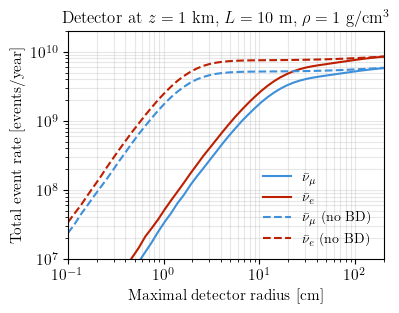

In [ ]:
fig, ax = pt.std_fig(figsize=(4, 3))

ax.plot(r_vals, n_total_numubar, label=r"$\bar{\nu}_\mu$", )
ax.plot(r_vals, n_total_nue, label=r"$\bar{\nu}_e$")

plt.gca().set_prop_cycle(None)

ax.plot(r_vals, n_total_numubar_noBD, label=r"$\bar{\nu}_\mu$ (no BD)", ls='--')
ax.plot(r_vals, n_total_nue_noBD, label=r"$\bar{\nu}_e$ (no BD)", ls='--')

ax.legend(frameon=False, fontsize=10, loc="lower right")
ax.grid(True, which="both", ls="-", alpha=0.3)

ax.set_xlim(0.1, 2e2)
ax.set_ylim(1e7, 2e10)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Maximal detector radius [cm]")
ax.set_ylabel("Total event rate [events/year]")
ax.set_title(r"Detector at $z = 1$ km, $L = 10$~m, $\rho = 1$ g/cm$^3$")


fig.tight_layout()
fig.savefig("plots/total_event_rate_vs_radius.pdf", dpi=300, bbox_inches="tight")

In [ ]:
# pull data of neutrino experiments
import os
import csv
nu_spectrum_dir = "nu_spectrum_data"
nu_spectrum_arrays = {}
for fname in os.listdir(nu_spectrum_dir):
    if fname.endswith(".csv"):
        arr = []
        with open(os.path.join(nu_spectrum_dir, fname), "r") as f:
            reader = csv.reader(f)
            for row in reader:
                if len(row) >= 2:
                    try:
                        x = float(row[0])
                        y = float(row[1])
                        arr.append((x, y))
                    except ValueError:
                        continue
        key = fname.replace(".csv", "").replace("_", " ")
        nu_spectrum_arrays[key] = arr
# Example: chorus = nu_spectrum_arrays["chorus"]
for key, arr in nu_spectrum_arrays.items():
    globals()[key] = arr

In [ ]:
nu_spectrum_arrays.keys()

dict_keys(['NOMAD', 'MuC 10TeV', 'CDHS', 'FPF', 'NuTeV', 'DUNE ND', 'CHORUS', 'FASER'])

## MuC comparison 

In [ ]:
L_det = 1e5  # cm (1 km)
event_results = get_event_rate(det_length=10e2, det_radius_cm=1e2, L_to_IP_cm=L_det)
event_results_2 = get_event_rate(det_length=10e2, det_radius_cm=2e2, L_to_IP_cm=L_det)
event_results_3 = get_event_rate(det_length=10e2, det_radius_cm=2e2, L_to_IP_cm=L_det)

L for 1 g/cm^3: 1000.0
Interaction probability for numubar : 1.4372175602969255e-08
Interaction probability for nue : 2.2785931130092873e-08
Interaction probability for numu : 2.2785931130092873e-08
L for 1 g/cm^3: 1000.0
Interaction probability for numubar : 1.4372175602969255e-08
Interaction probability for nue : 2.2785931130092873e-08
Interaction probability for numu : 2.2785931130092873e-08
L for 1 g/cm^3: 1000.0
Interaction probability for numubar : 1.4372175602969255e-08
Interaction probability for nue : 2.2785931130092873e-08
Interaction probability for numu : 2.2785931130092873e-08


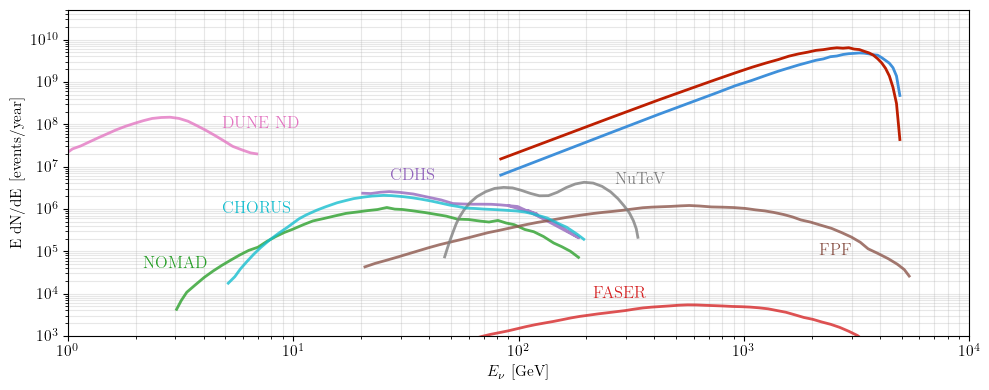

In [ ]:
# fig, ax = pt.std_fig()

fig, ax = plt.subplots(figsize=(10, 4))
line_handles = []

line, = ax.plot(energy_centers, event_results["numubar"]["dN_dE_per_year"]*energy_centers, lw=2, label=label["numubar"]+" (Latest Design)")
line, = ax.plot(energy_centers, event_results["nue"]["dN_dE_per_year"]*energy_centers, lw=2, label=label["nue"]+" (Latest Design)")
line_handles.append(line)
ax.set_xscale("log")
ax.set_yscale("log")

# Plot the sum of numubar and numu for the latest design
# sum_event = event_results["numubar"]["dN_dE_per_year"] * energy_centers + event_results["numu"]["dN_dE_per_year"] * energy_centers
# sum_line, = ax.plot(energy_centers, sum_event, lw=2, label=r"$\bar\nu_\mu + \nu_\mu$ (Latest Design)", color="black")
# ax.set_xscale("log")
# ax.set_yscale("log")

plt.gca().set_prop_cycle(None)

# Plot neutrino experiment data as lines
experiment_colors = ["tab:green", "grey", "tab:purple", "tab:brown", "tab:gray", "tab:pink", "tab:cyan", "tab:red"]
exp_line_handles = []
for i, (exp_name, arr) in enumerate(nu_spectrum_arrays.items()):
    arr = np.array(arr)
    if arr.shape[1] == 2:
        if exp_name in ["MuC 10TeV"]:
            ls = (1,(3,1))
            continue
        else:
            ls = '-'
        exp_line, = ax.plot(arr[:,0], arr[:,1], linestyle=ls, label=exp_name, lw=2, color=experiment_colors[i % len(experiment_colors)], alpha=0.8)
        exp_line_handles.append((exp_line, exp_name))

ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"E dN/dE [events/year]")
ax.set_xlim(1, 1e4)
ax.set_ylim(1e3, 5e10)
# Remove the default legend
# ax.legend(frameon=False, fontsize=12)
# ax.set_title(r"Neutrino Spectrum for a Detector at $z = 1$ km")
fig.tight_layout()

# Annotate each line with its label and color
# Now allow manual adjustment of label positions
# Provide a dictionary for manual label positions: {label: (x, y)}
manual_label_positions = {
    # Example: 'label_text': (x_value, y_value)
    # You can fill these in manually for each line
    r"$\bar\nu_\mu$ MuC 10 TeV": (110, 6e8),
    r"$\nu_e$ MuC 10 TeV": (70, 1e8),
    r"MuC 10TeV": (1000, 1.5e8),
    r"CHORUS": (4.5, 1e6),
    r"DUNE ND": (4.5, 1e8),
    r"NuTeV": (250, 5e6),
    r"FPF": (2000, 1e5),
    r"NOMAD": (2,5e4),
    r"CDHS": (25,6e6),
    r"FASER": (200, 1e4),
    r"$\nu_\mu$ MuC 10 TeV": (300, 2e9),
    "Latest Design": (270, 2e9)
}

def annotate_line(ax, line, label, xdata, ydata):
    if label in manual_label_positions:
        x_pos, y_pos = manual_label_positions[label]
    else:
        # Default: 70% along the line
        x_pos = xdata[0]
        y_pos = np.max(ydata) * 1.9
    ax.annotate(label,
                xy=(x_pos, y_pos),
                xytext=(5, 0),
                textcoords='offset points',
                color=line.get_color(),
                fontsize=12,
                va='center',
                ha='left',
                fontweight='bold')

# Annotate main design lines
# annotate_line(ax, line_handles[0], r"\noindent MuC 10 TeV "+label["numubar"]+r" \\($z=1$~km, $L=10$~m, $r=10$ cm, $10^3$ cycles)", energy_centers, event_results["numubar"]["dN_dE_per_year"]*energy_centers)
# annotate_line(ax, line_handles[1], r"\noindent MuC 10 TeV "+label["nue"]+r" \\($z=1$~km, $L=10$~m, $r=10$ cm, $10^3$ cycles)", energy_centers, event_results["nue"]["dN_dE_per_year"]*energy_centers)

# annotate_line(ax, sum_line, "Latest Design", energy_centers, sum_event)
ax.grid(True, which='both', ls='-', alpha=0.3)
# Annotate experiment lines
for exp_line, exp_name in exp_line_handles:
    xdata = exp_line.get_xdata()
    ydata = exp_line.get_ydata()
    # Only annotate if there is data
    if len(xdata) > 0 and len(ydata) > 0:
        annotate_line(ax, exp_line, exp_name, xdata, ydata)

fig.savefig("plots/numubar_spectrum.pdf", dpi=300, bbox_inches="tight")


# Energy spectrum (PRISM)

In [ ]:
radii_cm = np.linspace(0.1, 2e2, 10)  # cm
energy_spectra = []
for r_cm in radii_cm:
    energy_spectra.append(get_event_rate(det_length=10e2, det_radius_cm=r_cm, L_to_IP_cm=1e5))

L for 1 g/cm^3: 1000.0000000000001
Interaction probability for numubar : 1.4372175602969257e-08
Interaction probability for nue : 2.2785931130092873e-08
Interaction probability for numu : 2.2785931130092873e-08
L for 1 g/cm^3: 1000.0
Interaction probability for numubar : 1.4372175602969255e-08
Interaction probability for nue : 2.2785931130092873e-08
Interaction probability for numu : 2.2785931130092873e-08
L for 1 g/cm^3: 1000.0
Interaction probability for numubar : 1.4372175602969255e-08
Interaction probability for nue : 2.2785931130092873e-08
Interaction probability for numu : 2.2785931130092873e-08
L for 1 g/cm^3: 1000.0
Interaction probability for numubar : 1.4372175602969255e-08
Interaction probability for nue : 2.2785931130092873e-08
Interaction probability for numu : 2.2785931130092873e-08
L for 1 g/cm^3: 999.9999999999999
Interaction probability for numubar : 1.4372175602969253e-08
Interaction probability for nue : 2.278593113009287e-08
Interaction probability for numu : 2.2785

In [ ]:
# Energy spectrum of numubar for 19 radial annuli with 1 cm gaps (0–19 cm)
r_edges_cm = np.linspace(0, 5, 10)  # 20 edges → 19 annuli: [0-1], [1-2], ..., [18-19] cm
e_vals = np.linspace(0, 5e3, 51)  # GeV

er_edges = []
for r_cm in r_edges_cm:
    if r_cm == 0:
        er_edges.append(None)
    else:
        er_edges.append(get_event_rate(det_length=10e2, det_radius_cm=r_cm, L_to_IP_cm=1e5, e_edges=e_vals))


L for 1 g/cm^3: 1000.0
Interaction probability for numubar : 1.4467624835009943e-08
Interaction probability for nue : 2.292858286305168e-08
Interaction probability for numu : 2.292858286305168e-08
L for 1 g/cm^3: 1000.0
Interaction probability for numubar : 1.4467624835009943e-08
Interaction probability for nue : 2.292858286305168e-08
Interaction probability for numu : 2.292858286305168e-08
L for 1 g/cm^3: 1000.0000000000001
Interaction probability for numubar : 1.4467624835009945e-08
Interaction probability for nue : 2.2928582863051682e-08
Interaction probability for numu : 2.2928582863051682e-08
L for 1 g/cm^3: 1000.0
Interaction probability for numubar : 1.4467624835009943e-08
Interaction probability for nue : 2.292858286305168e-08
Interaction probability for numu : 2.292858286305168e-08
L for 1 g/cm^3: 1000.0
Interaction probability for numubar : 1.4467624835009943e-08
Interaction probability for nue : 2.292858286305168e-08
Interaction probability for numu : 2.292858286305168e-08
L

/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_24277/171939074.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


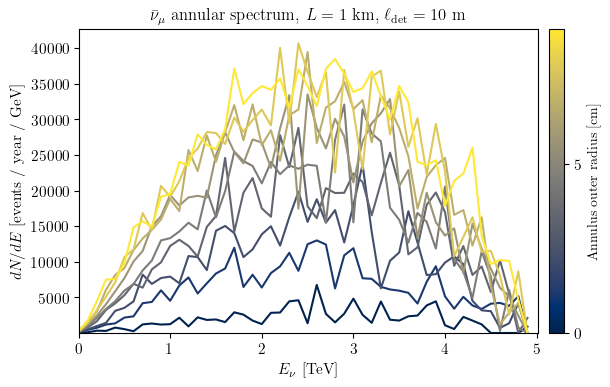

In [ ]:
n_annuli = len(r_edges_cm) - 1  # 19
cmap = plt.cm.cividis
colors = [cmap(i / (n_annuli - 1)) for i in range(n_annuli)]

fig, ax = pt.std_fig(figsize=(7, 4))

for i in range(n_annuli):
    spec_outer = er_edges[i + 1]["numubar"]["dN_dE_per_year"]
    spec_inner = np.zeros_like(spec_outer) if er_edges[i] is None else er_edges[i]["numubar"]["dN_dE_per_year"]
    annulus_spec = spec_outer - spec_inner
    ax.plot(e_vals[:-1] * 1e-3, annulus_spec, lw=1.5, color=colors[i])

# ax.set_xscale("log")
# ax.set_yscale("log")
ax.set_xlim(0, 5.01)
ax.set_xlabel(r"$E_\nu$ [TeV]")
ax.set_ylabel(r"$dN/dE$ [events / year / GeV]")
ax.set_ylim(bottom=1)
ax.set_title(r"$\bar\nu_\mu$ annular spectrum, $L = 1$ km, $\ell_\mathrm{det} = 10$ m")

# Colorbar to indicate annulus radius
import matplotlib.colors as mcolors
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0, vmax=n_annuli))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"Annulus outer radius [cm]", fontsize=10)
cbar.set_ticks(np.arange(0, n_annuli + 1, 5))

fig.tight_layout()
fig.savefig("plots/numubar_spectrum_annuli.pdf", dpi=300, bbox_inches="tight")
